# EDA — Amazon Dataset

Dataset: `data/raw/Amazon.csv`

Separate exploratory analysis for PricePilot AI.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

FILE = ROOT / "data" / "raw" / "Amazon.csv"
df = pd.read_csv(FILE)
print("Shape:", df.shape)
display(df.head())


Shape: (100000, 20)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [14]:
print("Columns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing"))
print("Duplicate rows:", df.duplicated().sum())


Columns: ['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']

Data types:


,dtype
OrderID,object
OrderDate,object
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64



Missing values:


,missing
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


Duplicate rows: 0


In [15]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
for c in ["Quantity","UnitPrice","Discount","Tax","ShippingCost","TotalAmount"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Date range:", df["OrderDate"].min(), "to", df["OrderDate"].max())
print("Unique products:", df["ProductID"].nunique())
print("Categories:", df["Category"].nunique())
display(df[["Quantity","UnitPrice","Discount","Tax","ShippingCost","TotalAmount"]].describe())


Date range: 2020-01-01 00:00:00 to 2024-12-29 00:00:00
Unique products: 50
Categories: 6


,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [16]:
if "OrderStatus" in df.columns:
    print("Order Status:")
    display(df["OrderStatus"].value_counts(dropna=False).to_frame("orders"))


Order Status:


,orders
OrderStatus,
Delivered,74628
Shipped,15192
Pending,4103
Returned,3049
Cancelled,3028


In [17]:
sales = df.copy()
if "OrderStatus" in sales.columns:
    delivered = sales[sales["OrderStatus"].astype(str).str.lower().eq("delivered")]
    if len(delivered) >= 100:
        sales = delivered

sales = sales[
    sales["OrderDate"].notna() &
    (sales["Quantity"] > 0) &
    (sales["UnitPrice"] > 0)
].copy()

sales["CalculatedRevenue"] = (
    sales["Quantity"] * sales["UnitPrice"] *
    (1 - sales["Discount"].fillna(0))
)

print("Rows used:", len(sales))
print("Total units:", sales["Quantity"].sum())
print("Calculated revenue:", sales["CalculatedRevenue"].sum())


Rows used: 74628
Total units: 223759
Calculated revenue: 62731303.56200001


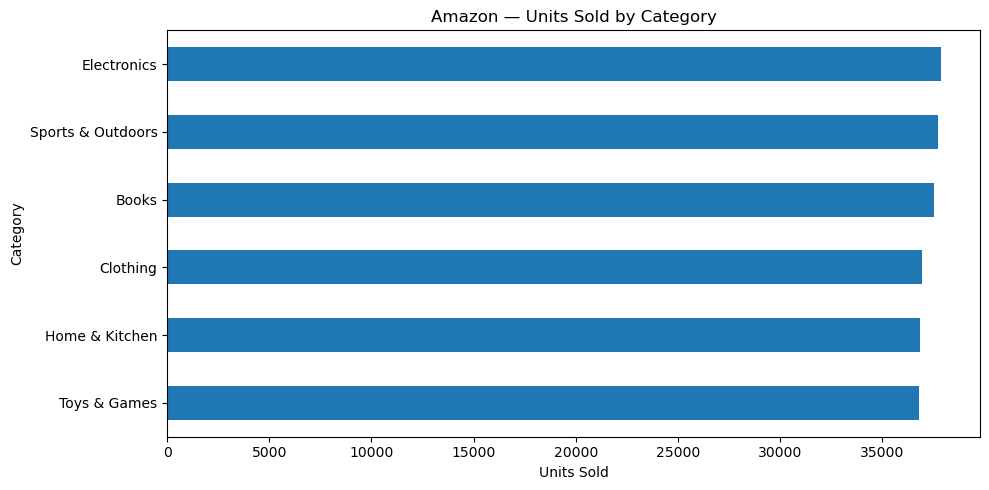

In [18]:
cat = sales.groupby("Category")["Quantity"].sum().sort_values()
plt.figure(figsize=(10,5))
cat.plot(kind="barh")
plt.title("Amazon — Units Sold by Category")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


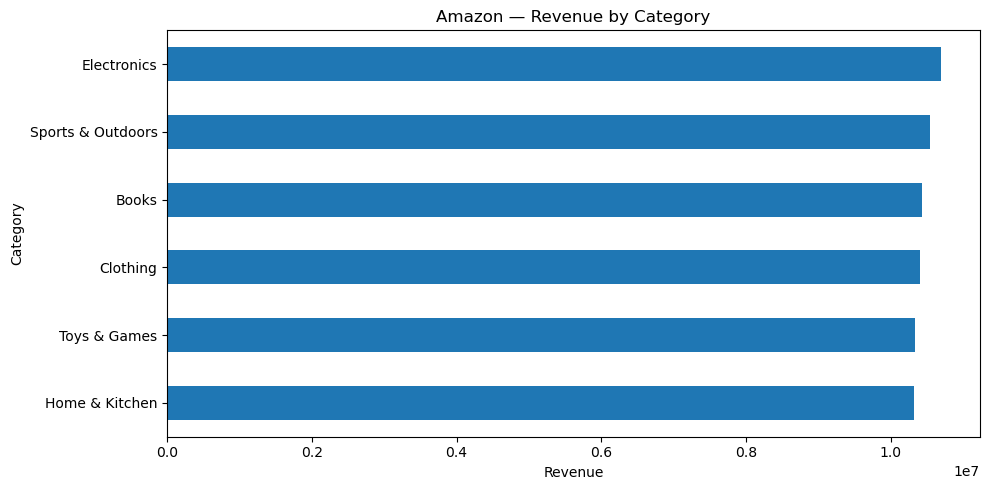

In [19]:
cat_rev = sales.groupby("Category")["CalculatedRevenue"].sum().sort_values()
plt.figure(figsize=(10,5))
cat_rev.plot(kind="barh")
plt.title("Amazon — Revenue by Category")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


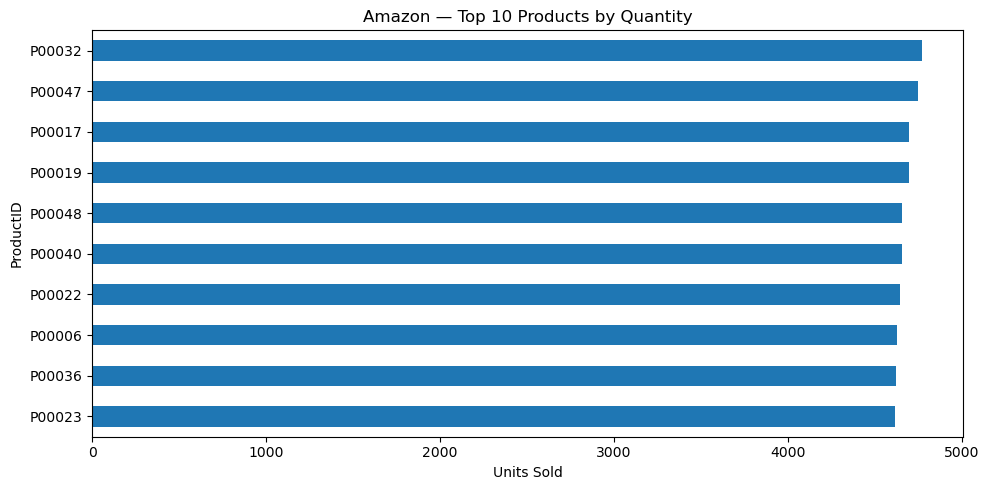

In [20]:
top = sales.groupby("ProductID")["Quantity"].sum().nlargest(10).sort_values()
plt.figure(figsize=(10,5))
top.plot(kind="barh")
plt.title("Amazon — Top 10 Products by Quantity")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


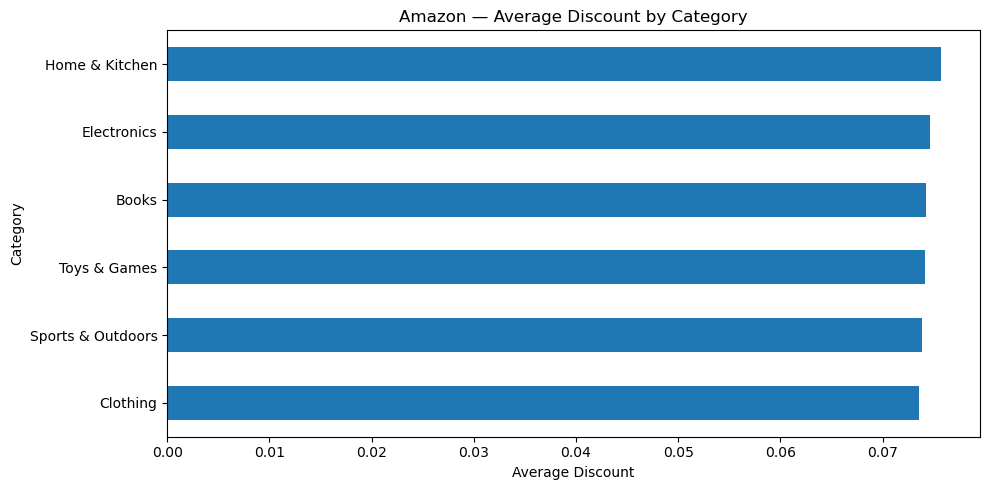

In [21]:
discount = sales.groupby("Category")["Discount"].mean().sort_values()
plt.figure(figsize=(10,5))
discount.plot(kind="barh")
plt.title("Amazon — Average Discount by Category")
plt.xlabel("Average Discount")
plt.tight_layout()
plt.show()


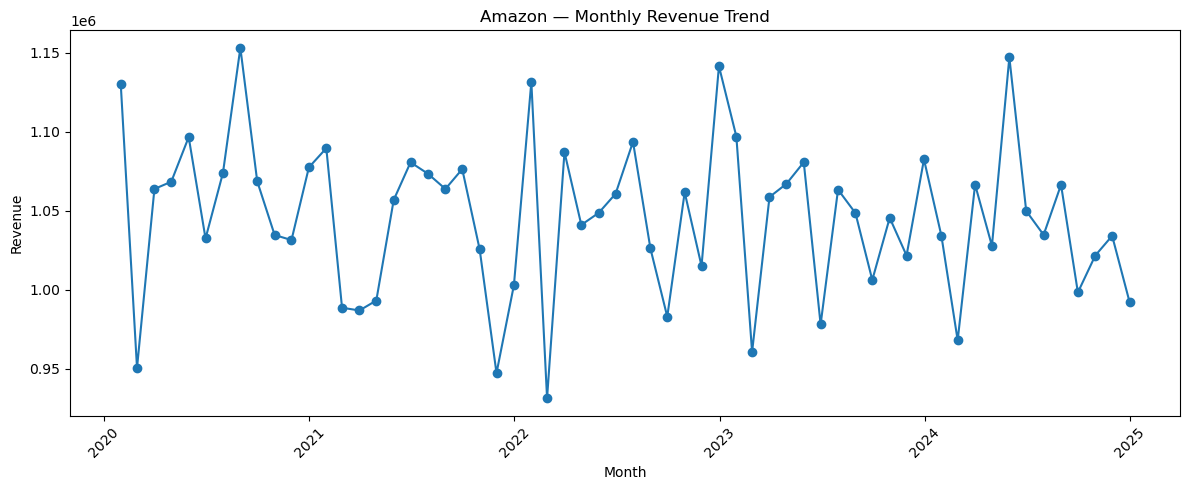

In [22]:
monthly = sales.set_index("OrderDate").resample("ME")["CalculatedRevenue"].sum()
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Amazon — Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
if "ShippingType" in sales.columns:
    shipping = sales["ShippingType"].value_counts()
    display(shipping.to_frame("orders"))
    plt.figure(figsize=(8,5))
    shipping.plot(kind="bar")
    plt.title("Amazon — Orders by Shipping Type")
    plt.xlabel("Shipping Type")
    plt.ylabel("Orders")
    plt.tight_layout()
    plt.show()


In [24]:
corr_cols = [c for c in ["Quantity","UnitPrice","Discount","Tax","ShippingCost","TotalAmount"] if c in sales.columns]
display(sales[corr_cols].corr())


,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
Quantity,1.000000,0.005824,0.002758,0.438088,0.021155,0.595599
UnitPrice,0.005824,1.000000,0.006227,0.526322,0.044716,0.716132
Discount,0.002758,0.006227,1.000000,-0.075121,0.001511,-0.105322
Tax,0.438088,0.526322,-0.075121,1.000000,0.022185,0.778801
ShippingCost,0.021155,0.044716,0.001511,0.022185,1.000000,0.038667
TotalAmount,0.595599,0.716132,-0.105322,0.778801,0.038667,1.000000


## Conclusion

The Amazon data provides demand, price, discount, product, category and order-date information suitable for Milestone 2 forecasting and pricing analysis.